# PBMC 3k — exploratory scRNA-seq analysis

## 0. Setup 

In [1]:
import sys
import scanpy as sc
import os
import numpy as np 
from scipy.stats import median_abs_deviation

In [2]:
os.chdir('..') # move notebook to project root 
os.getcwd()

'/Volumes/T7 Shield/Project_CV/scrnaseq-pipeline'

## 1. Load and explore the data

### 1.1 Dataset 
 Peripheral blood mononuclear cells (PBMCs) from a healthy donor (same donor as pbmc6k) sequenced with 10x Genomics Chromium. \
 PBMCs are primary cells with relatively small amounts of RNA (~1pg RNA/cell).

In [3]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

### 1.2 Anndata structure
obs = cells (barcodes), var = genes, X = UMI counts

In [4]:
adata.obs # cells barcode 

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1
...
TTTCGAACTCTCAT-1
TTTCTACTGAGGCA-1
TTTCTACTTCCTCG-1


In [5]:
adata.var

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180


In [6]:
type(adata.X) # sparse matrix do not store zero value -> save memory 


scipy.sparse._csr.csr_matrix

In [7]:
adata.X.toarray() # 0 can be a dropout an mRNA not detected 
                  # rows = cells    col = genes 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2700, 32738), dtype=float32)

In [8]:
adata.shape

(2700, 32738)

In [9]:
adata.X.nnz # number of non 0 value 

2286884

In [10]:
value = 1 - adata.X.nnz/(2700 * 32738)
f"{value:.1%}" # fraction of zero value 

'97.4%'

## 2. Quality Control 

### 2.1 mitochondrial genes 
In human start with "MT-". Human mitochondrial genomes has 37 genes : 13 protein-coding,  22 tRNAs and 2 rRNAs.


In [11]:
adata.var_names

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'KIR3DL2-1', 'AL590523.1', 'CT476828.1', 'PNRC2-1', 'SRSF10-1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='str', name='index', length=32738)

In [12]:
adata.var['MT-'] = adata.var_names.str.startswith('MT-') 
print("number of mitochondrial genes: " ,sum(adata.var['MT-']))

number of mitochondrial genes:  13


In [13]:
print("mitochondrial genes:" , adata.var_names[adata.var['MT-']])

mitochondrial genes: Index(['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3',
       'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='str', name='index')


### 2.2 QC metrics 
Mitochondrial percentage (pct_counts_MT-): \
Is calculated because damaged, dying, or stressed cells often have unusually high mitochondrial RNA fractions.\
\
Library size (total_counts): \
cells with small library sizes are of low quality as the RNA has been lost at some point during library preparation, either due to cell lysis or inefficient cDNA capture and amplification.\
\
number of expressed features in each cell (n_genes_by_counts): \
Any cell with very few expressed genes is likely to be of poor quality as the diverse transcript population has not been successfully captured.

In [14]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["MT-"], inplace= True )

In [15]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_MT-,log1p_total_counts_MT-,pct_counts_MT-
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242
...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,7.052721,3461.0,8.149602,39.237215,52.528171,65.761341,81.074834,73.0,4.304065,2.109217
TTTCTACTGAGGCA-1,1227,7.113142,3447.0,8.145550,37.278793,51.900203,63.881636,78.909196,32.0,3.496508,0.928343
TTTCTACTTCCTCG-1,622,6.434547,1684.0,7.429521,45.783848,61.638955,74.940618,92.755344,37.0,3.637586,2.197150


In [16]:
adata.obs.describe()[["n_genes_by_counts", "total_counts","pct_counts_MT-"]]

,n_genes_by_counts,total_counts,pct_counts_MT-
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.262085,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


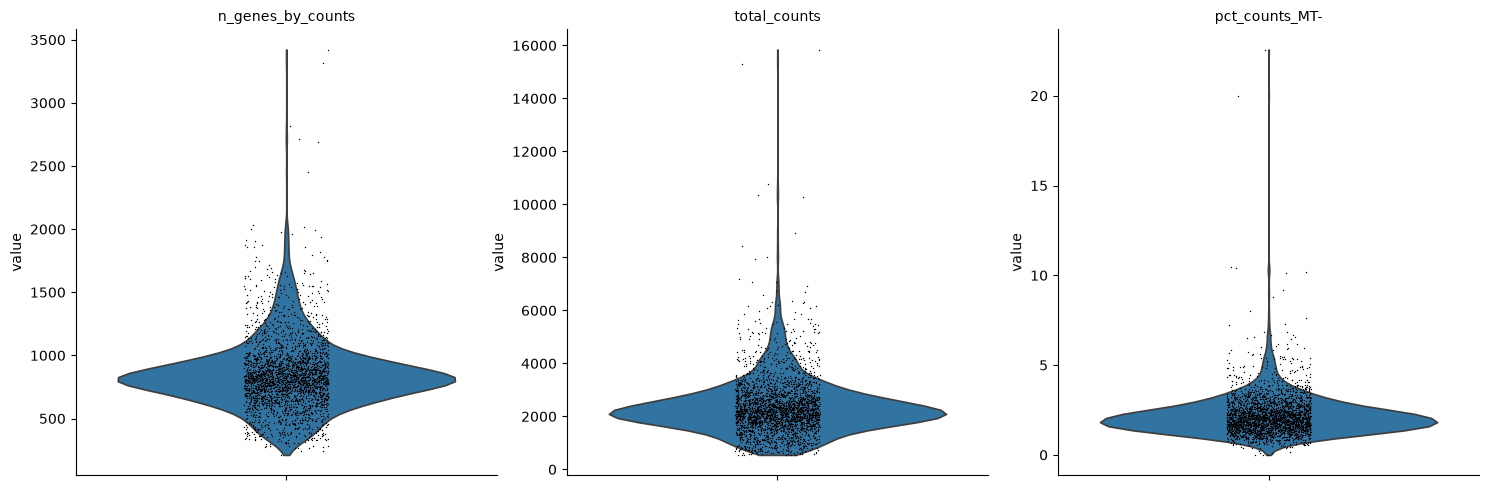

In [17]:
sc.pl.violin(adata, keys = ["n_genes_by_counts", "total_counts","pct_counts_MT-"], multi_panel=True )

### 2.3 MAD-based outlier detection
identify cells that are outliers for the different QC metrics 

In [18]:
def is_outlier(adata,col_name , nMAD,upper_only=False):
    MAD = median_abs_deviation(adata.obs[col_name])
    median = np.median(adata.obs[col_name])
    thresh_pos   = median + nMAD * MAD
    
    if upper_only == True:
        mask = adata.obs[col_name] > thresh_pos
        print("nb of oulier",col_name,"above:", sum(adata.obs[col_name] > thresh_pos))
        print("thresh used:" , "above", thresh_pos)
        
    else:
        thresh_under = median - nMAD * MAD
        mask = (adata.obs[col_name] > thresh_pos) | (adata.obs[col_name] < thresh_under)
        print("nb of oulier",col_name, ":", sum(mask))
        print("nb of oulier",col_name,"above:", sum(adata.obs[col_name] > thresh_pos))
        print("nb of oulier",col_name,"under:", sum(adata.obs[col_name] < thresh_under))
        print("thresh used:" , "above", thresh_pos, " and under " , thresh_under)
    return mask

adata.obs['outlier_n_genes_by_counts'] = is_outlier(adata, "log1p_n_genes_by_counts", 5)
adata.obs['outlier_total_counts'] = is_outlier(adata, "log1p_total_counts", 5)
adata.obs['outlier_pct_counts_MT-'] = is_outlier(adata, "pct_counts_MT-", 3, upper_only= True)
 

nb of oulier log1p_n_genes_by_counts : 79
nb of oulier log1p_n_genes_by_counts above: 20
nb of oulier log1p_n_genes_by_counts under: 59
thresh used: above 7.507217075898423  and under  5.90650759730707
nb of oulier log1p_total_counts : 58
nb of oulier log1p_total_counts above: 13
nb of oulier log1p_total_counts under: 45
thresh used: above 8.826466  and under  6.5641403
nb of oulier pct_counts_MT- above: 202
thresh used: above 3.6501262


In [19]:
adata.obs["qc_fail"] = (adata.obs['outlier_n_genes_by_counts'])|(adata.obs['outlier_total_counts'] )|(adata.obs['outlier_pct_counts_MT-'] )
print("outlier_n_genes_by_counts:",sum(adata.obs["outlier_n_genes_by_counts"]))
print("outlier_total_counts:",sum(adata.obs["outlier_total_counts"]))
print("outlier_pct_counts_MT-:",sum(adata.obs["outlier_pct_counts_MT-"]))
print("qc_fail:",sum(adata.obs["qc_fail"]))
print("% of outlier: ",adata.obs["qc_fail"].mean())

outlier_n_genes_by_counts: 79
outlier_total_counts: 58
outlier_pct_counts_MT-: 202
qc_fail: 266
% of outlier:  0.09851851851851852


### 2.4 Filtering cells
266 cells filtered based on MAD on the 3 metrics 

In [20]:
adata_clean = adata[~adata.obs["qc_fail"] ].copy()
adata_clean

AnnData object with n_obs × n_vars = 2434 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT-', 'log1p_total_counts_MT-', 'pct_counts_MT-', 'outlier_n_genes_by_counts', 'outlier_total_counts', 'outlier_pct_counts_MT-', 'qc_fail'
    var: 'gene_ids', 'MT-', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: None (.X)

### 2.5 Filtering genes
19259 genes filtered

In [21]:
sc.pp.filter_genes(adata_clean,min_cells=3)
adata_clean

AnnData object with n_obs × n_vars = 2434 × 13479
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT-', 'log1p_total_counts_MT-', 'pct_counts_MT-', 'outlier_n_genes_by_counts', 'outlier_total_counts', 'outlier_pct_counts_MT-', 'qc_fail'
    var: 'gene_ids', 'MT-', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: None (.X)

## 3. Doublet detection